In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [7]:
X, y = make_classification(n_features=5, n_redundant=0, n_clusters_per_class=1)

In [8]:
df = pd.DataFrame(X, columns=['col1', 'col2','col3', 'col4','col5'])
df['target'] = y
print(df.shape)
df.sample(3)

(100, 6)


,col1,col2,col3,col4,col5,target
20,-0.755915,-1.149802,-1.943228,-1.657077,-0.891884,1
18,0.043985,-0.789191,0.722778,-0.673624,-0.880515,1
55,0.667501,-1.575950,-0.321852,-0.218557,0.612941,1


In [9]:
def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]), replace=True)

In [10]:
def sample_features(df, percent):
  cols = random.saple(df.columns.tolist()[:-1], int(percent*df.shape[1]))
  return df[cols]

In [11]:
def combined_sampling(df, r_per, c_per):
  new_df = sample_rows(df, r_per)
  return sample_features(new_df, c_per)

In [12]:
df1 = sample_rows(df, 0.1)

In [13]:
df2 = sample_rows(df, 0.1)

In [14]:
df3 = sample_rows(df, 0.1)

In [15]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [16]:
clf1.fit(df1.iloc[:,0:5], df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5], df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5], df3.iloc[:,-1])

DecisionTreeClassifier()

In [17]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[3] <= 0.177\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.625, 0.5, '  False')]

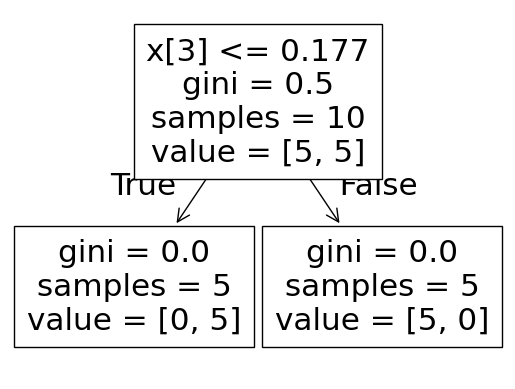

In [18]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[3] <= -0.111\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.625, 0.5, '  False')]

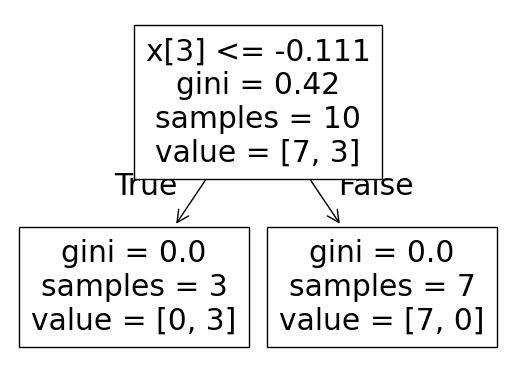

In [19]:
plot_tree(clf2)

[Text(0.5, 0.75, 'x[4] <= 0.137\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

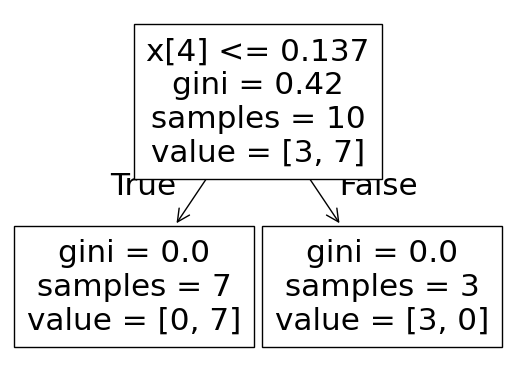

In [20]:
plot_tree(clf3)

In [23]:
clf1.predict(np.array([-1.654426,	-0.127857	,0.325818,	2.186719,	-0.468670]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [24]:

clf2.predict(np.array([-1.654426,	-0.127857	,0.325818,	2.186719,	-0.468670]).reshape(1,5))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [25]:
clf3.predict(np.array([-1.654426,	-0.127857	,0.325818,	2.186719,	-0.468670]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

## ------------------------------------


In [26]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [27]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

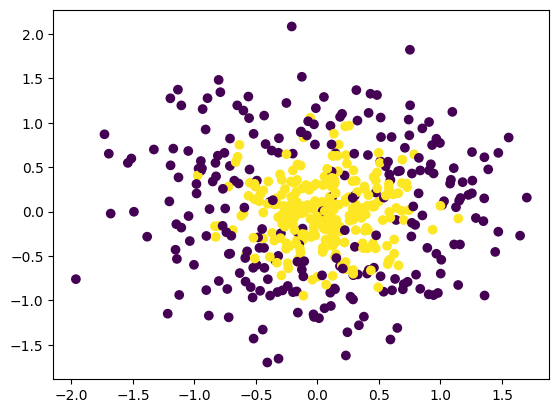

In [28]:
plt.scatter(X[:,0], X[:,1], c=y)

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
dt = DecisionTreeClassifier(max_depth=None)
dt.fit(X_train, y_train)

DecisionTreeClassifier()

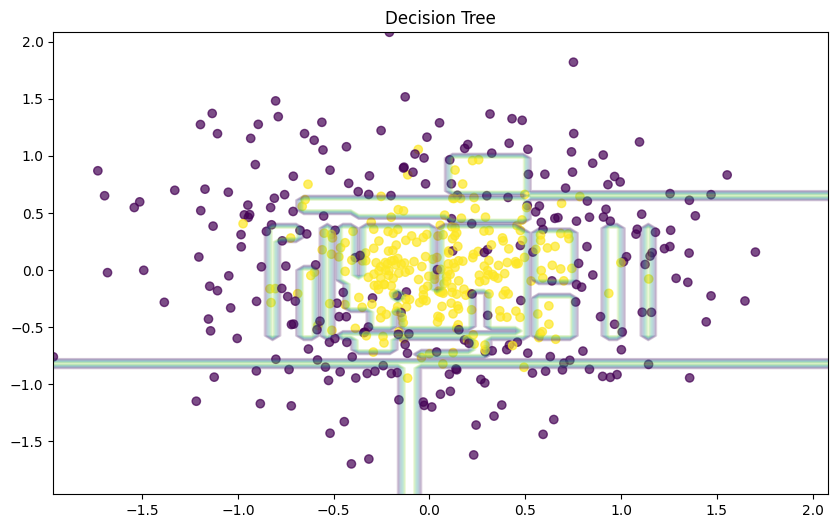

In [33]:
plt.figure(figsize=(10,6))
x_range = np.linspace(X.min(), X.max(), 100)
xx1 , xx2 = np.meshgrid(x_range, x_range)
y_hat = dt.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contour(xx1, xx2,y_hat, alpha=0.2)
plt.scatter(X[:,0],X[:,1],c=y, cmap='viridis', alpha=0.7)
plt.title('Decision Tree')
plt.show()

In [34]:
from sklearn.ensemble import RandomForestClassifier

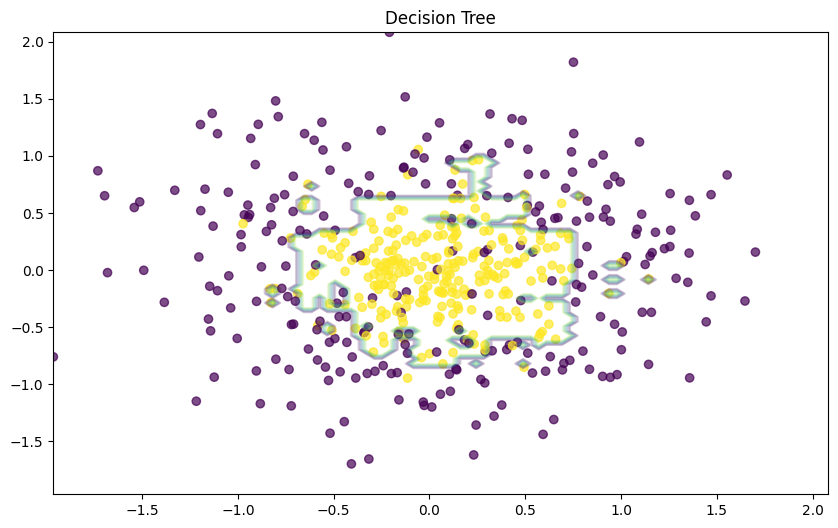

In [35]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contour(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
plt.title('Decision Tree')
plt.show()

### Regressor

In [40]:
n_train = 150
n_test = 1000
noise = 0.1

def f(x):
  x = x.ravel()
  return np.exp(-x**2) + 1.5*np.exp(-(x-2)**2)

def generate(n_samples, noise):
  X = np.random.rand(n_samples)*10 - 5
  X = np.sort(X).ravel()
  y = np.exp(-X**2)+1.5*np.exp(-(X - 2)**2) + np.random.normal(0.0, noise, n_samples)
  X = X.reshape((n_samples, 1))
  return X, y

In [41]:
X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

(-5.0, 5.0)

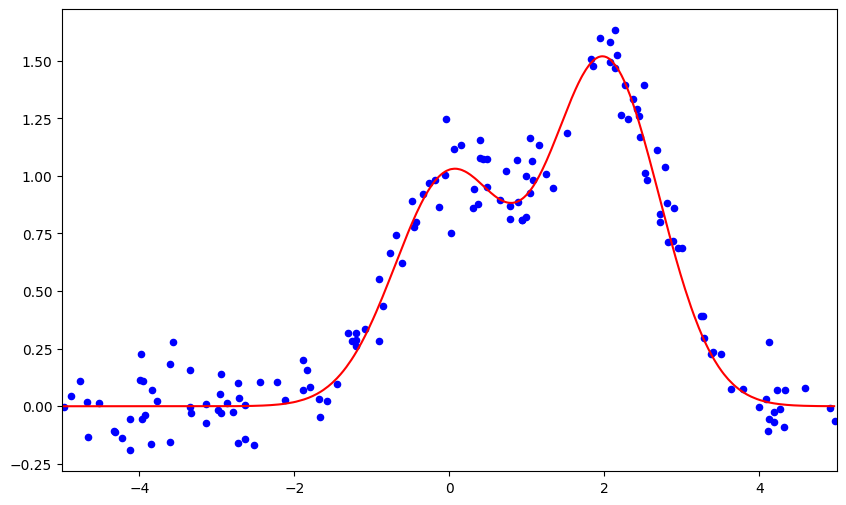

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), 'r')
plt.scatter(X_train, y_train, c='b', s=20)
plt.xlim([-5,5])

Text(0.5, 1.0, 'Decision tree, MSE : 126.01')

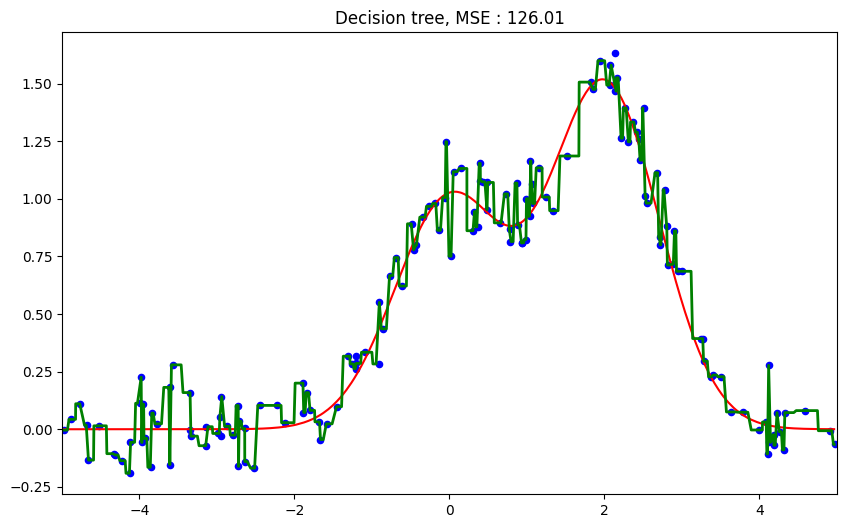

In [51]:
# one dt regressor
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor().fit(X_train, y_train)
d_pred = dt.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), 'r')
plt.scatter(X_train, y_train, c='b', s=20)
plt.plot(X_test, d_pred, 'g', lw=2)
plt.xlim([-5,5])
plt.title('Decision tree, MSE : %.2f'%np.sum(y_test - d_pred)**2)

Text(0.5, 1.0, 'Random Forest, MSE : 56.28')

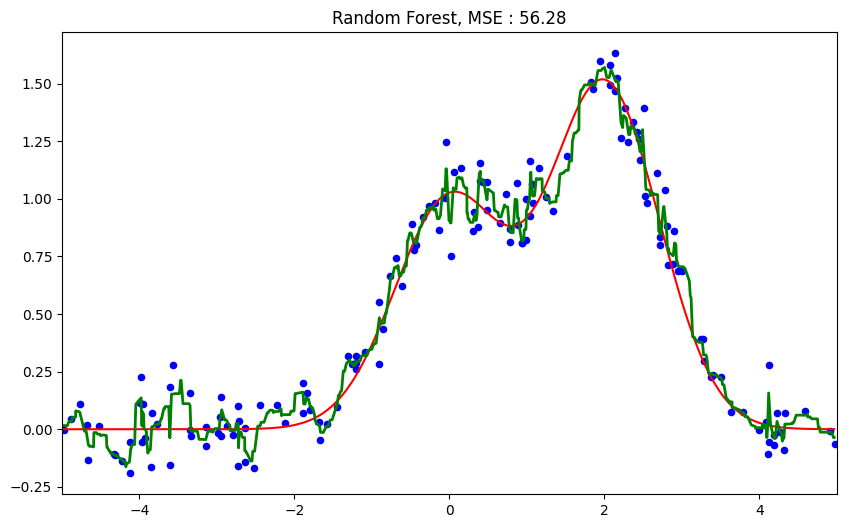

In [53]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_pred = rfr.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), 'r')
plt.scatter(X_train, y_train, c='b', s=20)
plt.plot(X_test, rf_pred, 'g', lw=2)
plt.xlim([-5,5])
plt.title('Random Forest, MSE : %.2f'%np.sum(y_test - rf_pred)**2)
